In [1]:
include("src/polyatree.jl")
include("src/partitions.jl")

using Distributions
using Plots
using Serialization
using DataFrames
using LaTeXStrings
using Plots.PlotMeasures
using Printf

In [2]:
sigmoid(x) = 1 / (1 + exp(-x))
sigmoid_inv(y) = log(y / (1 - y))
sigmoid_prime(x) = sigmoid(x) * (1 - sigmoid(x))
sigmoid_prime_from_x(x) = x .* (1 .- x)


sigmoid(x, s) = sigmoid(x / s)
sigmoid_inv(y, s) = s * sigmoid_inv(y)
sigmoid_prime(x, s) = (1 / s) * sigmoid_prime(x / s)
sigmoid_prime_from_x(x, s) = (1/s) * x * (1 - x)


probit(x) = cdf(Normal(), x)
probit_inv(y) = quantile(Normal(), y)
probit_prime(x) = pdf(Normal(), x)

probit(x, s) = cdf(Normal(), x/s)
probit_inv(y, s) = s * quantile(Normal(), y)
probit_prime(x, s) = 1/s * pdf(Normal(), x/s)


probit_prime (generic function with 2 methods)

In [3]:
orig_data = [rand(TDist(3), 1000) .- 4.0; rand(Normal(3.0, 1.0), 2000)]

3000-element Vector{Float64}:
 -0.8349938518838944
 -3.46229187347045
 -4.752937918883327
 -3.7492820850256914
 -7.6748016689308765
 -2.1728217808304544
 -4.0940881746676006
 -3.6567801624094356
 -2.6104945812685014
 -5.096381258203218
  ⋮
  4.009922671082359
  2.842397561776929
  0.48818162482226457
  4.718655196019331
  2.919186791476989
  1.931192964073336
  3.1031305671529545
  3.771949035385475
  2.5321403534721925

In [12]:
xgrid = collect(LinRange(1e-3, 1.0 - 1e-3, 3000))

s = sqrt(var(orig_data))
s = 1.0
sigmoid_data = sigmoid.(orig_data ./ s)
gfpt1 = GFPT1(Poisson(7.0), 10, 0.05)
pt = gfpt1.pt
pt = update(sigmoid_data, pt)
mean_dens = predictive_density(xgrid, pt)

ygrid = sigmoid_inv.(xgrid, s)
est_dens = mean_dens .* sigmoid_prime_from_x.(xgrid, s)
plot(ygrid, est_dens, lw=2, label="PT", xlabel="x", 
     ylabel="PT", alpha=0.6)


gfpt1 = GFPT1(Poisson(5.0), 10, 0.1)
gfpt1 = update(sigmoid_data, gfpt1)
mean_dens = predictive_density(xgrid, gfpt1)

ygrid = sigmoid_inv.(xgrid, s)
est_dens = mean_dens .* sigmoid_prime_from_x.(xgrid, s)

if s == 1.0
    title_str = "Logistic transformation: No scaling"
else
    title_str = "Logistic transformation: Proper scaling"
end

plot!(ygrid, est_dens, lw=2, label="GFPT1", xlabel="x", 
     ylabel="Density", title=title_str,
     xlim=(-10, 6))

histogram!(orig_data, normalize=true, nbins=100, alpha=0.3, label="Data histogram")

if s == 1.0
    savefig("plots/sigmoid_transformation_noscale.pdf")
else
    savefig("plots/sigmoid_transformation_properscale.pdf")
end

"/Users/marioberaha/Documents/uni/papers/polyatree/code/plots/sigmoid_transformation_noscale.pdf"

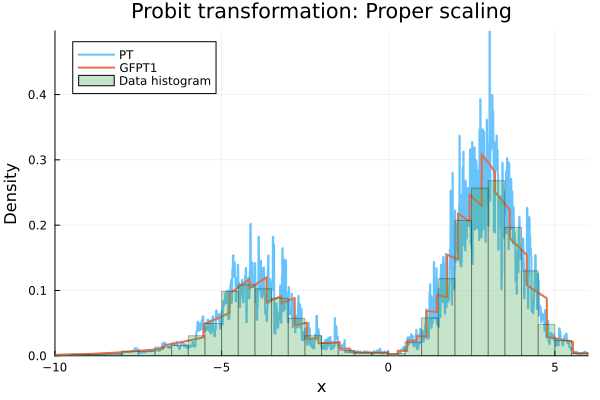

In [5]:
xgrid = collect(LinRange(1e-10, 1.0 - 1e-10, 3000))

s = sqrt(var(orig_data))
# s = 1.0
probit_data = probit.(orig_data, s);

gfpt1 = GFPT1(Poisson(7.0), 10, 0.05)
pt = gfpt1.pt
pt = update(probit_data, pt)
mean_dens = predictive_density(xgrid, pt)

ygrid = probit_inv.(xgrid, s)
est_dens = mean_dens .* probit_prime.(ygrid, s)
plot(ygrid, est_dens, lw=2, label="PT", xlabel="x", alpha=0.6)

gfpt1 = GFPT1(Poisson(5.0), 10, 0.1)
gfpt1 = update(probit_data, gfpt1)
mean_dens = predictive_density(xgrid, gfpt1)

ygrid = probit_inv.(xgrid, s)
est_dens = mean_dens .* probit_prime.(ygrid, s)


if s == 1.0
    title_str = "Probit transformation: No scaling"
else
    title_str = "Probit transformation: Proper scaling"
end

plot!(ygrid, est_dens, lw=2, label="GFPT1", xlabel="x", 
     ylabel="Density", title=title_str,
     xlim=(-10, 6))

histogram!(orig_data, normalize=true, nbins=100, alpha=0.3, label="Data histogram")

# if s == 1.0
#     savefig("plots/probit_transformation_noscale.pdf")
# else
#     savefig("plots/probit_transformation_properscale.pdf")
# end

In [21]:
scaled_logistic(x, s) = 1 ./ (1 .+ x.^(-1/s))
inv_scaled_logistic(u, s) = (u ./ (1 .- u)).^s
scaled_logistic_prime(x, s) = 1 ./ (s .* x .* (1 .+ x.^(1/s)).^2)


softplus_normalized(x) = (log1p.(x)) ./ (1 .+ log1p.(x))
inv_softplus_normalized(u) = exp.(u ./ (1 .- u)) .- 1
softplus_normalized_prime(x) = 1 ./ ( (1 .+ log1p.(x)).^2 .* (1 .+ x) )



# -------------------------------------------------------
# Symmetric log-arctan transform: ℝ⁺ → (0,1)
# -------------------------------------------------------

"""
    log_arctan_transform(x, m, s)

Symmetric bijection from ℝ⁺ to (0,1) based on log(x):

    z(x) = (log(x) - m) / s
    T(x) = 0.5 + (1/π) * atan(z(x))

m, s typically are location/scale parameters of log-data, e.g.
m = mean(log.(data)), s = std(log.(data)).
"""
function log_arctan_transform(x, m, s)
    z = (log.(x) .- m) ./ s
    return 0.5 .+ atan.(z) ./ π
end


"""
    inv_log_arctan_transform(u, m, s)

Inverse of the log-arctan transform:

    z = tan(π*(u - 0.5))
    x = exp(m + s * z)
"""
function inv_log_arctan_transform(u, m, s)
    z = tan.(π .* (u .- 0.5))
    return exp.(m .+ s .* z)
end


"""
    log_arctan_prime(x, m, s)

Jacobian T'(x):

    z(x) = (log(x) - m) / s
    T'(x) = 1 / [π * s * x * (1 + z(x)^2)]
"""
function log_arctan_prime(x, m, s)
    z = (log.(x) .- m) ./ s
    return 1.0 ./ (π .* s .* x .* (1 .+ z.^2))
end


log_arctan_prime

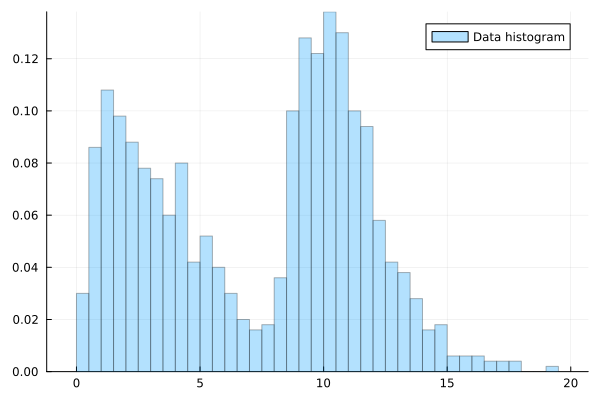

In [29]:
orig_data = [rand(Gamma(2, 2), 500); rand(Gamma(3.0, 1.0), 500) .+ 8.0 ]
s = sqrt(var(orig_data))

histogram(orig_data, normalize=true, nbins=40, alpha=0.3, label="Data histogram")


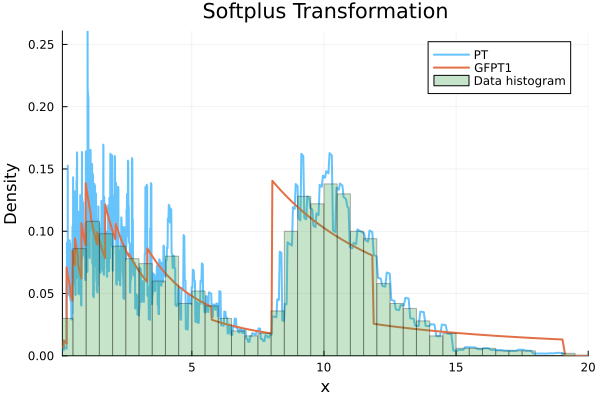

In [31]:
xgrid = collect(LinRange(1e-2, 1.0 - 1e-2, 3000))

s = 1.0
softplus_data = softplus_normalized.(orig_data)

gfpt1 = GFPT1(Poisson(7.0), 10, 0.05)
pt = gfpt1.pt
pt = update(softplus_data, pt)
mean_dens = predictive_density(xgrid, pt)

ygrid = inv_softplus_normalized.(xgrid)
est_dens = mean_dens .* softplus_normalized_prime.(ygrid)
plot(ygrid, est_dens, lw=2, label="PT", xlabel="x", 
     ylabel="PT", alpha=0.6)


gfpt1 = GFPT1(Poisson(5.0), 10, 0.1)
gfpt1 = update(softplus_data, gfpt1)
mean_dens = predictive_density(xgrid, gfpt1)

est_dens = mean_dens .* softplus_normalized_prime.(ygrid)
plot!(ygrid, est_dens, lw=2, label="GFPT1", xlabel="x", 
     ylabel="Density", title="Softplus Transformation",
     xlim=(0.1, 20))


histogram!(orig_data, normalize=true, nbins=40, alpha=0.3, label="Data histogram")

# savefig("plots/softplus_transformation.pdf")

In [33]:
# data
# orig_data = [rand(Gamma(2, 2), 500); rand(Gamma(3.0, 1.0), 500) .+ 8.0]


# estimate m, s on the log scale
log_data = log.(orig_data)
m = mean(log_data)
s = std(log_data)
u_data_sigmoid = sigmoid.(log_data .- m, s)


# fit GFPT on [0,1]
ugrid = collect(LinRange(1e-3, 1 - 1e-3, 3000))

zgrid = sigmoid_inv.(ugrid, s) .+ m  # z-grid on ℝ
xgrid = exp.(zgrid)                    # x-grid on ℝ⁺
jac = (1 ./ (s .* xgrid)) .* (ugrid .* (1 .- ugrid))


gfpt1 = GFPT1(Poisson(5.0), 10, 0.1)
pt = gfpt1.pt
pt = update(u_data_sigmoid, pt)
mean_u = predictive_density(ugrid, pt)

# Jacobian du/dx using u = ugrid
est_dens = mean_u .* jac

plot(xgrid, est_dens, lw=2, alpha=0.6, label="PT", xlim=(0.1, 20), )




gfpt1 = GFPT1(Poisson(5.0), 10, 0.05)
gfpt1 = update(u_data_sigmoid, gfpt1)
mean_u = predictive_density(ugrid, gfpt1)

# Jacobian du/dx using u = ugrid
est_dens = mean_u .* jac

plot!(xgrid, est_dens, lw=2, label="GFPT1", xlim=(0.1, 20), 
     title="Log + Sigmoid Transformation",  xlabel="x", 
     ylabel="Density")

histogram!(orig_data, normalize=true, nbins=40, alpha=0.3, label="Data histogram")
savefig("plots/log_sigmoid_transformation.pdf")

"/Users/marioberaha/Documents/uni/papers/polyatree/code/plots/log_sigmoid_transformation.pdf"